# Predictive Maintenance ML Pipeline (AI4I 2020)

We compare:
- Logistic Regression (interpretable baseline)
- Random Forest (bagging)
- XGBoost (boosting)

Business decision policy:
If predicted failure probability **p ≥ τ**, trigger preventive maintenance (inspection/maintenance).  
We choose **τ** to minimize expected cost.

Data:
The Kaggle dataset “Predictive Maintenance Dataset AI4I 2020”

Outputs:
- Model comparison table (PR-AUC, ROC-AUC, F1, Recall@Precision>=0.80, Brier, Cost/1000)
- Cost curves and alerts-per-1000 vs threshold
- Calibration curves (uncalibrated vs calibrated XGBoost)
- Explainability (Permutation importance; optional SHAP)

Notes:
- We avoid random split. We sort by UDI and use a blocked train/test split (last 20% as test).

In [ ]:
# If needed, you can install the required libraries using pip:
# !pip install -U pandas numpy scikit-learn xgboost seaborn matplotlib shap

import os
import json
import math
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.base import clone
from sklearn.model_selection import TimeSeriesSplit
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline

from sklearn.metrics import (
    roc_auc_score, average_precision_score,
    precision_recall_curve,
    f1_score, precision_score, recall_score,
    confusion_matrix, brier_score_loss
)

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.calibration import CalibratedClassifierCV, calibration_curve
from sklearn.inspection import permutation_importance

from xgboost import XGBClassifier

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

sns.set_theme(style="whitegrid")

## 1) Load data + schema normalization

In [8]:

data = "ai4i2020.csv"

df = pd.read_csv(data)
df.columns = [c.strip() for c in df.columns]

print("Shape:", df.shape)
display(df.head(3))

# Target column
target_candidates = ["Machine failure", "machine failure", "Target", "target", "Failure", "failure"]
target_col = next((c for c in target_candidates if c in df.columns), None)
if target_col is None:
    raise ValueError(f"Could not find target column. Columns: {list(df.columns)}")

df[target_col] = df[target_col].astype(int)
print("Target:", target_col, "| Positive rate:", round(df[target_col].mean(), 4))

# Ordering column (UDI typical)
uid_candidates = ["UDI", "Uid", "uid", "ID", "Id"]
uid_col = next((c for c in uid_candidates if c in df.columns), None)
if uid_col is None:
    print("Warning: No UDI/ID column found. Using index ordering.")
    df["_order"] = np.arange(len(df))
    uid_col = "_order"

Shape: (10000, 14)


,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0


Target: Machine failure | Positive rate: 0.0339


## 2) Quick EDA (imbalance + sensor distributions)

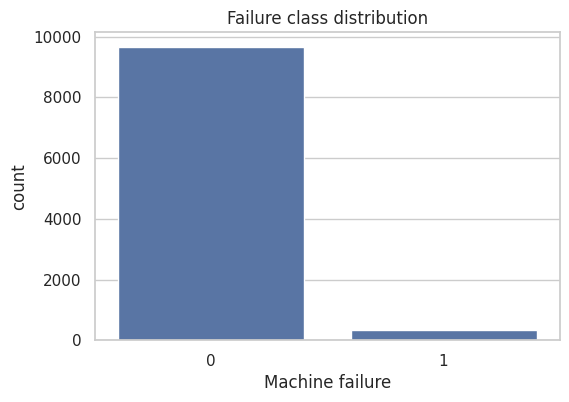

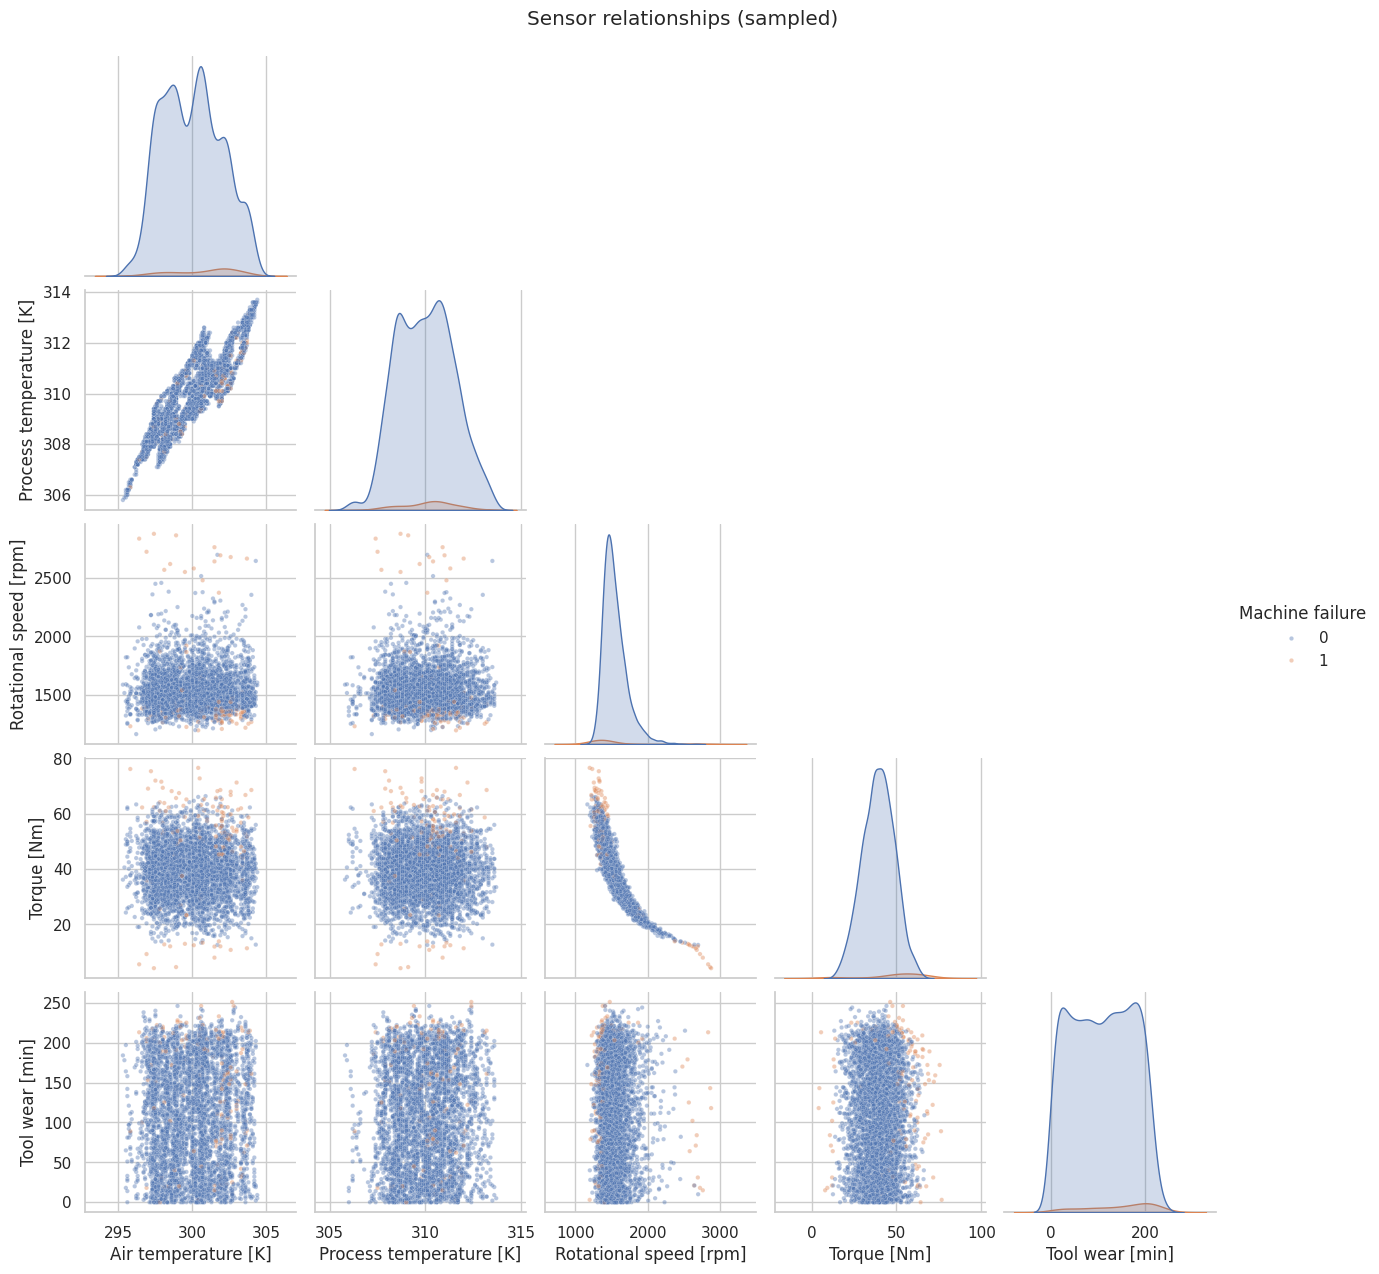

In [9]:
fig, ax = plt.subplots(figsize=(6, 4))
sns.countplot(x=target_col, data=df, ax=ax)
ax.set_title("Failure class distribution")
plt.show()

sensor_cols = [
    "Air temperature [K]",
    "Process temperature [K]",
    "Rotational speed [rpm]",
    "Torque [Nm]",
    "Tool wear [min]"
]
present_sensors = [c for c in sensor_cols if c in df.columns]

if present_sensors:
    sample = df[present_sensors + [target_col]].sample(
        min(len(df), 4000), random_state=RANDOM_STATE
    )
    g = sns.pairplot(sample, hue=target_col, corner=True, plot_kws=dict(alpha=0.4, s=10))
    g.fig.suptitle("Sensor relationships (sampled)", y=1.02)
    plt.show()
else:
    print("Standard sensor columns not found; skipping pairplot.")

## 3) Feature engineering

We use two feature sets:
- F0 (raw): Type + core sensors
- F1 (engineered): F0 + domain-inspired features:
  - temp_delta = process - air
  - omega_rad_s = 2π*rpm/60
  - power_W_proxy = torque * omega_rad_s
  - overstrain_idx = tool_wear * torque
  - torque_per_rpm = torque / (rpm + 1)


In [10]:
df_fe = df.copy()

type_col = "Type" if "Type" in df_fe.columns else ("type" if "type" in df_fe.columns else None)

col_map = {
    "air_temp": "Air temperature [K]",
    "proc_temp": "Process temperature [K]",
    "rpm": "Rotational speed [rpm]",
    "torque": "Torque [Nm]",
    "wear": "Tool wear [min]",
}

# Engineered features (only if inputs exist)
if col_map["proc_temp"] in df_fe.columns and col_map["air_temp"] in df_fe.columns:
    df_fe["temp_delta"] = df_fe[col_map["proc_temp"]] - df_fe[col_map["air_temp"]]

if col_map["rpm"] in df_fe.columns:
    df_fe["omega_rad_s"] = 2 * math.pi * df_fe[col_map["rpm"]] / 60.0

if col_map["torque"] in df_fe.columns and "omega_rad_s" in df_fe.columns:
    df_fe["power_W_proxy"] = df_fe[col_map["torque"]] * df_fe["omega_rad_s"]

if col_map["wear"] in df_fe.columns and col_map["torque"] in df_fe.columns:
    df_fe["overstrain_idx"] = df_fe[col_map["wear"]] * df_fe[col_map["torque"]]

if col_map["torque"] in df_fe.columns and col_map["rpm"] in df_fe.columns:
    df_fe["torque_per_rpm"] = df_fe[col_map["torque"]] / (df_fe[col_map["rpm"]] + 1.0)

display(df_fe.head(3))

,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF,temp_delta,omega_rad_s,power_W_proxy,overstrain_idx,torque_per_rpm
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0,10.5,162.420340,6951.590560,0.0,0.027577
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0,10.5,147.445415,6826.722724,138.9,0.032860
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0,10.4,156.870193,7749.387543,247.0,0.032955


## 4) Train/test split (blocked)

We avoid random split. We sort by UDI and hold out the last 20% as test.
This mimics deployment: train on earlier runs, predict on later runs.

In [11]:
df_fe = df_fe.sort_values(uid_col).reset_index(drop=True)

test_frac = 0.20
cut = int(len(df_fe) * (1 - test_frac))

train_df = df_fe.iloc[:cut].copy()
test_df  = df_fe.iloc[cut:].copy()

y_train = train_df[target_col].values
y_test  = test_df[target_col].values

print("Train:", train_df.shape, "Test:", test_df.shape)
print("Train pos rate:", round(y_train.mean(), 4), "Test pos rate:", round(y_test.mean(), 4))

Train: (8000, 19) Test: (2000, 19)
Train pos rate: 0.0375 Test pos rate: 0.0195


## 5) Feature sets + preprocessing

Preprocessing:
- One-hot encode Type (if present)
- Standardize numeric variables

We keep one consistent preprocessing pattern across models for a fair comparison.

In [12]:
# Columns to drop from features
drop_cols = {target_col}
for c in ["UDI", "Product ID", "ProductID", "product_id", "Failure Type", "failure_type"]:
    if c in df_fe.columns:
        drop_cols.add(c)
for c in ["TWF", "HDF", "PWF", "OSF", "RNF"]:
    if c in df_fe.columns:
        drop_cols.add(c)

# F0: Type + core sensors (if present)
F0_cols = []
for c in [type_col, col_map["air_temp"], col_map["proc_temp"], col_map["rpm"], col_map["torque"], col_map["wear"]]:
    if c and c in df_fe.columns and c not in drop_cols:
        F0_cols.append(c)

# F1: add engineered
engineered_cols = [c for c in ["temp_delta", "omega_rad_s", "power_W_proxy", "overstrain_idx", "torque_per_rpm"] if c in df_fe.columns]
F1_cols = list(dict.fromkeys(F0_cols + engineered_cols))

print("F0:", F0_cols)
print("F1:", F1_cols)

def make_preprocessor(feature_cols):
    cat_cols = [type_col] if (type_col and type_col in feature_cols) else []
    num_cols = [c for c in feature_cols if c not in cat_cols]
    return ColumnTransformer(
        transformers=[
            ("num", StandardScaler(), num_cols),
            ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols),
        ],
        remainder="drop"
    ), num_cols, cat_cols

pre_F0, num_F0, cat_F0 = make_preprocessor(F0_cols)
pre_F1, num_F1, cat_F1 = make_preprocessor(F1_cols)

# Imbalance weight for XGBoost
pos = y_train.sum()
neg = len(y_train) - pos
scale_pos_weight = (neg / pos) if pos > 0 else 1.0
print("scale_pos_weight:", round(scale_pos_weight, 2))

X_train_F0 = train_df[F0_cols].copy()
X_test_F0  = test_df[F0_cols].copy()
X_train_F1 = train_df[F1_cols].copy()
X_test_F1  = test_df[F1_cols].copy()

# Blocked CV on train (for OOF threshold selection)
tscv = TimeSeriesSplit(n_splits=4)

F0: ['Type', 'Air temperature [K]', 'Process temperature [K]', 'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]']
F1: ['Type', 'Air temperature [K]', 'Process temperature [K]', 'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]', 'temp_delta', 'omega_rad_s', 'power_W_proxy', 'overstrain_idx', 'torque_per_rpm']
scale_pos_weight: 25.67


## 6) Metrics + cost-based threshold selection

We optimize the decision threshold using expected cost.

Cost model:
- C_PM: cost per preventive action (TP + FP)
- C_F: cost per missed failure (FN)

Total cost = C_PM*(TP+FP) + C_F*FN
We report cost per 1,000 cycles.

In [13]:
def recall_at_precision(y_true, y_prob, min_precision=0.80):
    prec, rec, thr = precision_recall_curve(y_true, y_prob)
    mask = prec[:-1] >= min_precision
    if not np.any(mask):
        return 0.0, None
    idx = np.argmax(rec[:-1][mask])
    chosen_thr = thr[mask][idx]
    chosen_rec = rec[:-1][mask][idx]
    return float(chosen_rec), float(chosen_thr)

def evaluate_probs(y_true, y_prob, thr=0.5):
    y_pred = (y_prob >= thr).astype(int)
    return {
        "PR_AUC": average_precision_score(y_true, y_prob),
        "ROC_AUC": roc_auc_score(y_true, y_prob),
        "F1": f1_score(y_true, y_pred, zero_division=0),
        "Precision": precision_score(y_true, y_pred, zero_division=0),
        "Recall": recall_score(y_true, y_pred, zero_division=0),
        "Brier": brier_score_loss(y_true, y_prob),
    }

def cost_curve(y_true, y_prob, c_pm=1.0, c_f=20.0, n_points=200):
    thresholds = np.linspace(0.0, 1.0, n_points)
    costs = np.zeros_like(thresholds)
    alerts = np.zeros_like(thresholds, dtype=int)
    for i, t in enumerate(thresholds):
        y_pred = (y_prob >= t).astype(int)
        tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0,1]).ravel()
        costs[i] = c_pm*(tp+fp) + c_f*fn
        alerts[i] = int(tp+fp)
    return thresholds, costs, alerts

def choose_threshold_min_cost(y_true, y_prob, c_pm=1.0, c_f=20.0, max_alerts=None):
    th, costs, alerts = cost_curve(y_true, y_prob, c_pm=c_pm, c_f=c_f)
    if max_alerts is not None:
        feasible = alerts <= max_alerts
        if not np.any(feasible):
            idx = np.argmax(th)
        else:
            idx = np.where(feasible)[0][np.argmin(costs[feasible])]
    else:
        idx = int(np.argmin(costs))
    return float(th[idx]), float(costs[idx]), int(alerts[idx])

# Business costs (edit to match your story)
C_PM = 1.0
C_F  = 20.0
print("Costs: C_PM =", C_PM, "C_F =", C_F)

Costs: C_PM = 1.0 C_F = 20.0


## 7) OOF predictions (blocked CV) for honest threshold selection

We pick τ* on out-of-fold predictions from the training set, not on the fitted training probabilities.
This prevents overly optimistic threshold choice.

In [14]:
def oof_predict_proba(estimator, X, y, cv):
    oof = np.zeros(len(y), dtype=float)
    for fold, (tr, va) in enumerate(cv.split(X)):
        est_fold = clone(estimator)
        est_fold.fit(X.iloc[tr], y[tr])
        oof[va] = est_fold.predict_proba(X.iloc[va])[:, 1]
    return oof

## 8) Model builders (LogReg, RF, XGB)

In [15]:
def make_lr(preprocessor):
    return Pipeline([
        ("pre", preprocessor),
        ("model", LogisticRegression(
            max_iter=2000,
            class_weight="balanced",
            solver="lbfgs"
        ))
    ])

def make_rf(preprocessor):
    return Pipeline([
        ("pre", preprocessor),
        ("model", RandomForestClassifier(
            n_estimators=400,
            min_samples_leaf=2,
            class_weight="balanced_subsample",
            random_state=RANDOM_STATE,
            n_jobs=-1
        ))
    ])

def make_xgb(preprocessor):
    return Pipeline([
        ("pre", preprocessor),
        ("model", XGBClassifier(
            n_estimators=600,
            max_depth=4,
            learning_rate=0.05,
            subsample=0.9,
            colsample_bytree=0.9,
            reg_lambda=1.0,
            objective="binary:logistic",
            eval_metric="logloss",
            random_state=RANDOM_STATE,
            n_jobs=-1,
            scale_pos_weight=scale_pos_weight
        ))
    ])

## 9) Experiments (F0 vs F1): LR vs RF vs XGB

For each model:
1) OOF on train
2) Choose τ* minimizing cost on OOF
3) Fit on full train
4) Evaluate on held-out test using τ*

In [16]:
def run_feature_set(name, X_tr, X_te, preprocessor):
    ests = {
        "LogReg": make_lr(preprocessor),
        "RandForest": make_rf(preprocessor),
        "XGBoost": make_xgb(preprocessor),
    }
    rows = []
    fitted = {}
    oof_probs = {}
    tau_star = {}

    for model_name, est in ests.items():
        oof = oof_predict_proba(est, X_tr, y_train, tscv)
        oof_probs[model_name] = oof

        tau, cost_oof, alerts_oof = choose_threshold_min_cost(
            y_train, oof, c_pm=C_PM, c_f=C_F
        )
        tau_star[model_name] = tau

        train_metrics = evaluate_probs(y_train, oof, thr=tau)
        train_rec80, _ = recall_at_precision(y_train, oof, min_precision=0.80)

        est_fit = clone(est)
        est_fit.fit(X_tr, y_train)
        fitted[model_name] = est_fit

        te_prob = est_fit.predict_proba(X_te)[:, 1]
        test_metrics = evaluate_probs(y_test, te_prob, thr=tau)
        test_rec80, _ = recall_at_precision(y_test, te_prob, min_precision=0.80)

        y_pred = (te_prob >= tau).astype(int)
        tn, fp, fn, tp = confusion_matrix(y_test, y_pred, labels=[0,1]).ravel()
        cost = C_PM*(tp+fp) + C_F*fn
        cost_per_1000 = 1000.0 * cost / len(y_test)
        alerts_per_1000 = 1000.0 * (tp+fp) / len(y_test)

        rows.append({
            "FeatureSet": name,
            "Model": model_name,
            "Tau*(OOF)": tau,
            "Train PR-AUC": train_metrics["PR_AUC"],
            "Train ROC-AUC": train_metrics["ROC_AUC"],
            "Train F1@Tau*": train_metrics["F1"],
            "Train Recall@Prec>=0.80": train_rec80,
            "Test PR-AUC": test_metrics["PR_AUC"],
            "Test ROC-AUC": test_metrics["ROC_AUC"],
            "Test F1@Tau*": test_metrics["F1"],
            "Test Recall@Prec>=0.80": test_rec80,
            "Test Brier": test_metrics["Brier"],
            "Test Cost/1000": cost_per_1000,
            "Test Alerts/1000": alerts_per_1000
        })

    return pd.DataFrame(rows), fitted, oof_probs, tau_star

res_F0, fit_F0, oof_F0, thr_F0 = run_feature_set("F0_raw", X_train_F0, X_test_F0, pre_F0)
res_F1, fit_F1, oof_F1, thr_F1 = run_feature_set("F1_engineered", X_train_F1, X_test_F1, pre_F1)

results = pd.concat([res_F0, res_F1], ignore_index=True)
display(results.sort_values(["FeatureSet", "Test Cost/1000"]))

,FeatureSet,Model,Tau*(OOF),Train PR-AUC,Train ROC-AUC,Train F1@Tau*,Train Recall@Prec>=0.80,Test PR-AUC,Test ROC-AUC,Test F1@Tau*,Test Recall@Prec>=0.80,Test Brier,Test Cost/1000,Test Alerts/1000
2,F0_raw,XGBoost,0.035176,0.306015,0.734812,0.319366,0.110000,0.725426,0.971535,0.352941,0.564103,0.012776,134.0,74.0
1,F0_raw,RandForest,0.040201,0.270641,0.804138,0.223084,0.043333,0.693032,0.948470,0.272000,0.615385,0.010634,155.5,105.5
0,F0_raw,LogReg,0.713568,0.247498,0.711296,0.259406,0.030000,0.424312,0.902222,0.411765,0.128205,0.036021,264.5,14.5
4,F1_engineered,RandForest,0.020101,0.482464,0.826279,0.219178,0.396667,0.766329,0.948836,0.293878,0.717949,0.007963,133.0,103.0
5,F1_engineered,XGBoost,0.080402,0.446297,0.719455,0.422442,0.376667,0.784155,0.960159,0.554455,0.717949,0.006863,141.0,31.0
3,F1_engineered,LogReg,0.527638,0.237297,0.741742,0.231748,0.050000,0.372189,0.923548,0.314465,0.128205,0.045296,200.0,60.0


## 10) Summary plots (business KPI + PR-AUC)

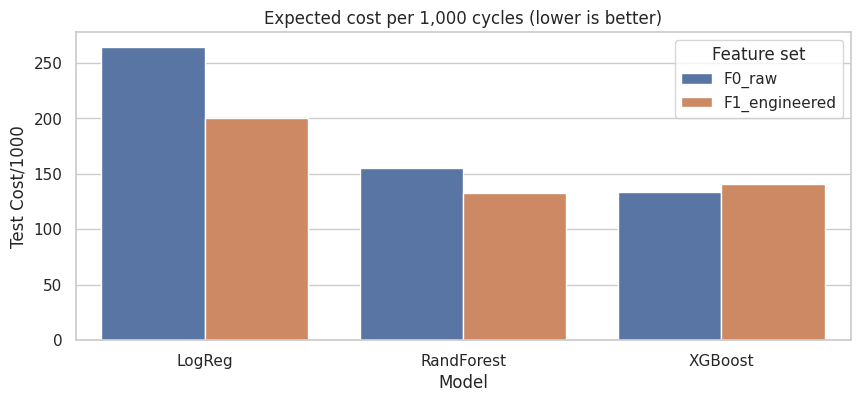

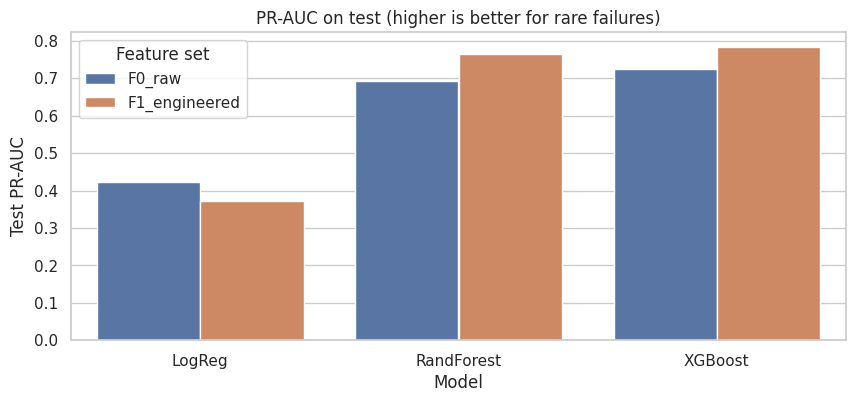

In [17]:
fig, ax = plt.subplots(figsize=(10, 4))
sns.barplot(data=results, x="Model", y="Test Cost/1000", hue="FeatureSet", ax=ax)
ax.set_title("Expected cost per 1,000 cycles (lower is better)")
plt.legend(title="Feature set")
plt.show()

fig, ax = plt.subplots(figsize=(10, 4))
sns.barplot(data=results, x="Model", y="Test PR-AUC", hue="FeatureSet", ax=ax)
ax.set_title("PR-AUC on test (higher is better for rare failures)")
plt.legend(title="Feature set")
plt.show()

## 11) Cost curve for best model (F1)

This is the figure you use to justify the chosen threshold policy to a business audience.

Best model on F1 by cost: RandForest | tau* = 0.0201


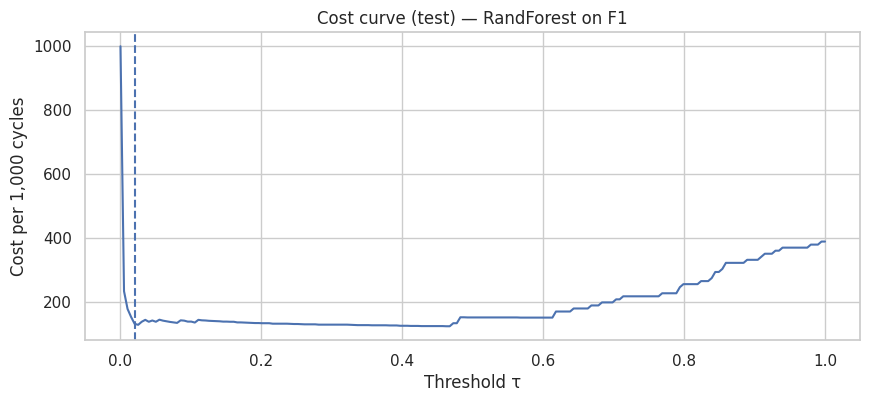

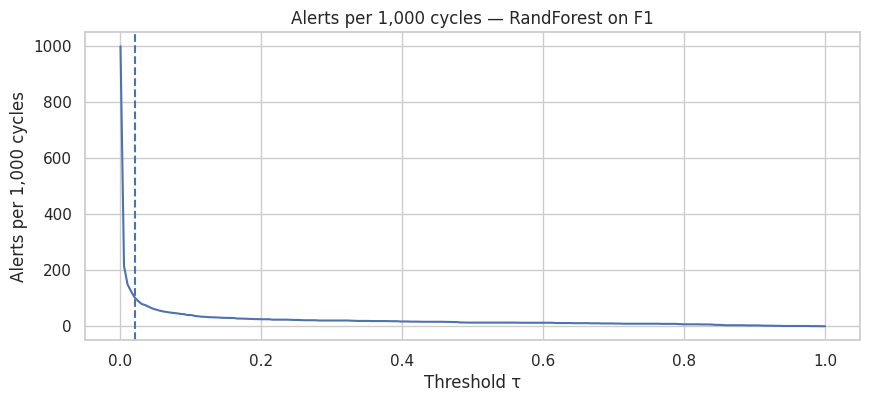

In [18]:
best_row = results[results["FeatureSet"]=="F1_engineered"].sort_values("Test Cost/1000").iloc[0]
best_model = best_row["Model"]
best_tau = float(best_row["Tau*(OOF)"])

print("Best model on F1 by cost:", best_model, "| tau* =", round(best_tau, 4))

best_est = fit_F1[best_model]
best_prob = best_est.predict_proba(X_test_F1)[:, 1]

th, costs, alerts = cost_curve(y_test, best_prob, c_pm=C_PM, c_f=C_F)
cost_per_1000 = 1000.0 * costs / len(y_test)
alerts_per_1000 = 1000.0 * alerts / len(y_test)

fig, ax = plt.subplots(figsize=(10, 4))
sns.lineplot(x=th, y=cost_per_1000, ax=ax)
ax.axvline(best_tau, linestyle="--")
ax.set_title(f"Cost curve (test) — {best_model} on F1")
ax.set_xlabel("Threshold τ")
ax.set_ylabel("Cost per 1,000 cycles")
plt.show()

fig, ax = plt.subplots(figsize=(10, 4))
sns.lineplot(x=th, y=alerts_per_1000, ax=ax)
ax.axvline(best_tau, linestyle="--")
ax.set_title(f"Alerts per 1,000 cycles — {best_model} on F1")
ax.set_xlabel("Threshold τ")
ax.set_ylabel("Alerts per 1,000 cycles")
plt.show()

## 12) Probability calibration (XGBoost)

Calibration matters because you act on probabilities. We compare uncalibrated vs calibrated XGBoost on the test set.

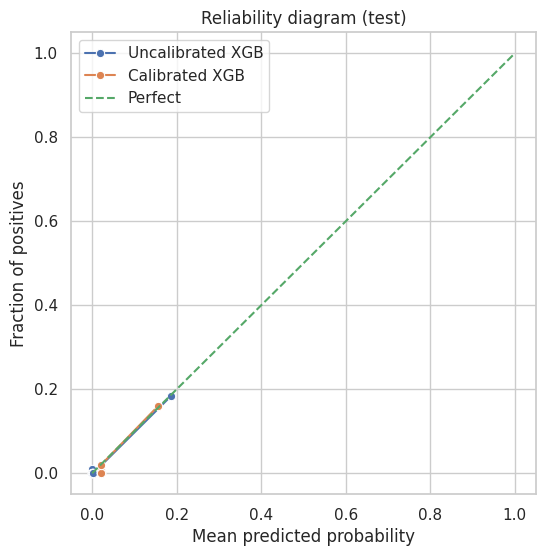

Brier uncal: 0.006863
Brier cal:   0.007637
Test tau* uncal: 0.005 | cost/1000: 115.0
Test tau* cal:   0.4472 | cost/1000: 125.5


In [19]:
# Uncalibrated XGB
xgb_uncal = make_xgb(pre_F1).fit(X_train_F1, y_train)
prob_uncal = xgb_uncal.predict_proba(X_test_F1)[:, 1]

# Calibrated XGB (sigmoid/Platt scaling) using blocked CV on train
xgb_pipe = make_xgb(pre_F1)
cal = CalibratedClassifierCV(estimator=xgb_pipe, method="sigmoid", cv=tscv)
cal.fit(X_train_F1, y_train)
prob_cal = cal.predict_proba(X_test_F1)[:, 1]

fig, ax = plt.subplots(figsize=(6, 6))
for label, p in [("Uncalibrated XGB", prob_uncal), ("Calibrated XGB", prob_cal)]:
    frac_pos, mean_pred = calibration_curve(y_test, p, n_bins=10, strategy="quantile")
    sns.lineplot(x=mean_pred, y=frac_pos, marker="o", label=label, ax=ax)
sns.lineplot(x=[0,1], y=[0,1], linestyle="--", label="Perfect", ax=ax)
ax.set_title("Reliability diagram (test)")
ax.set_xlabel("Mean predicted probability")
ax.set_ylabel("Fraction of positives")
ax.legend()
plt.show()

print("Brier uncal:", round(brier_score_loss(y_test, prob_uncal), 6))
print("Brier cal:  ", round(brier_score_loss(y_test, prob_cal), 6))

# Demonstrate cost-optimal thresholds on test (not for training; for interpretation)
tau_u, cost_u, _ = choose_threshold_min_cost(y_test, prob_uncal, c_pm=C_PM, c_f=C_F)
tau_c, cost_c, _ = choose_threshold_min_cost(y_test, prob_cal, c_pm=C_PM, c_f=C_F)

print("Test tau* uncal:", round(tau_u, 4), "| cost/1000:", round(1000*cost_u/len(y_test), 3))
print("Test tau* cal:  ", round(tau_c, 4), "| cost/1000:", round(1000*cost_c/len(y_test), 3))

## 13) Explainability

Permutation importance. SHAP for XGBoost.

,feature,importance_mean,importance_std
9,overstrain_idx,0.271600,0.016811
0,Type,0.112478,0.027124
8,power_W_proxy,0.089416,0.023593
5,Tool wear [min],0.069403,0.003579
4,Torque [Nm],0.030284,0.006896
10,torque_per_rpm,0.008138,0.008428
7,omega_rad_s,0.003592,0.004793
6,temp_delta,0.001743,0.001717
2,Process temperature [K],-0.002640,0.001990
3,Rotational speed [rpm],-0.004613,0.004752


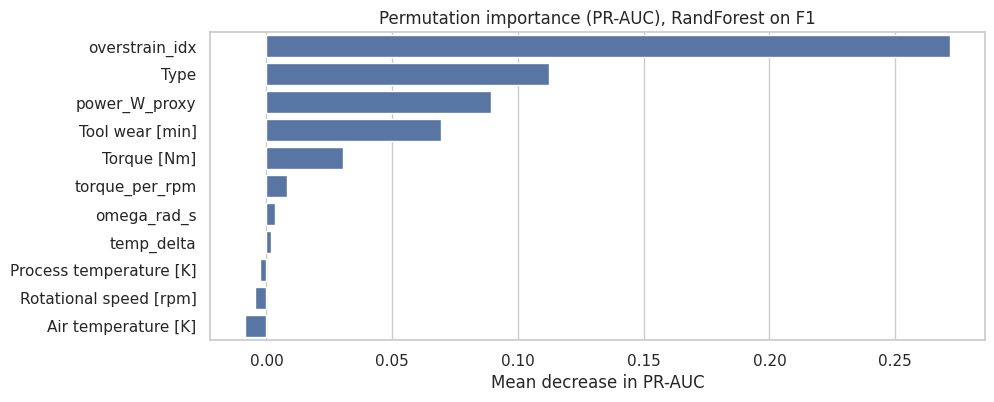

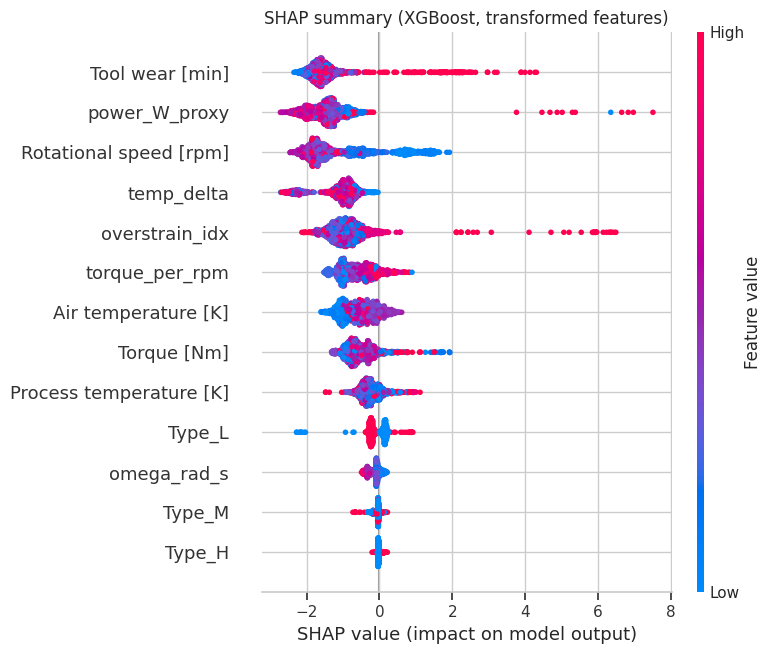

In [ ]:
best_est = fit_F1[best_model]
perm = permutation_importance(
    best_est, X_test_F1, y_test,
    n_repeats=10, random_state=RANDOM_STATE,
    scoring="average_precision"
)

imp = pd.DataFrame({
    "feature": X_test_F1.columns,
    "importance_mean": perm.importances_mean,
    "importance_std": perm.importances_std,
}).sort_values("importance_mean", ascending=False)

display(imp.head(10))

fig, ax = plt.subplots(figsize=(10, 4))
sns.barplot(data=imp.head(12), x="importance_mean", y="feature", ax=ax)
ax.set_title(f"Permutation importance (PR-AUC), {best_model} on F1")
ax.set_xlabel("Mean decrease in PR-AUC")
ax.set_ylabel("")
plt.show()

try:
    import shap
    shap.initjs()

    # Transform features using the same preprocessor structure
    pre = pre_F1
    X_tr_t = pre.fit_transform(X_train_F1)
    X_te_t = pre.transform(X_test_F1)

    feat_names = list(num_F1)
    if cat_F1:
        ohe = pre.named_transformers_["cat"]
        feat_names += list(ohe.get_feature_names_out(cat_F1))

    xgb = XGBClassifier(
        n_estimators=600, max_depth=4, learning_rate=0.05,
        subsample=0.9, colsample_bytree=0.9, reg_lambda=1.0,
        objective="binary:logistic", eval_metric="logloss",
        random_state=RANDOM_STATE, n_jobs=-1, scale_pos_weight=scale_pos_weight
    )
    xgb.fit(X_tr_t, y_train)

    explainer = shap.TreeExplainer(xgb)
    shap_vals = explainer.shap_values(X_te_t)

    shap.summary_plot(shap_vals, X_te_t, feature_names=feat_names, show=False)
    plt.title("SHAP summary (XGBoost, transformed features)")
    plt.tight_layout()
    plt.show()

except Exception as e:
    print("SHAP skipped:", e)

## 14) Export artifacts

- results table as CSV
- thresholds/cost settings as JSON

In [21]:
os.makedirs("artifacts", exist_ok=True)

results.to_csv("artifacts/model_comparison_results.csv", index=False)

thresholds_export = {
    "F0": thr_F0,
    "F1": thr_F1,
    "costs": {"C_PM": C_PM, "C_F": C_F},
    "best_model_F1_by_cost": best_model
}
with open("artifacts/thresholds.json", "w") as f:
    json.dump(thresholds_export, f, indent=2)

print("Saved: artifacts/model_comparison_results.csv")
print("Saved: artifacts/thresholds.json")

Saved: artifacts/model_comparison_results.csv
Saved: artifacts/thresholds.json
